In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [46]:
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [3]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'megaGymDataset.csv'

df = pd.read_csv(file_path)

In [5]:
df.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [6]:
df.Type.unique()

<StringArray>
[             'Strength',           'Plyometrics',                'Cardio',
            'Stretching',          'Powerlifting',             'Strongman',
 'Olympic Weightlifting']
Length: 7, dtype: str

In [8]:
df.Type.value_counts()

Type
Strength                 2545
Stretching                147
Plyometrics                97
Powerlifting               37
Cardio                     35
Olympic Weightlifting      35
Strongman                  22
Name: count, dtype: int64

In [7]:
df[df.Type == 'Strength'].BodyPart.value_counts()

BodyPart
Abdominals     644
Quadriceps     516
Shoulders      305
Chest          239
Biceps         165
Triceps        139
Lats           113
Middle Back    113
Lower Back      73
Glutes          67
Hamstrings      65
Calves          33
Forearms        27
Traps           22
Abductors       12
Adductors        6
Neck             6
Name: count, dtype: int64

In [9]:
df[df.Type == 'Olympic Weightlifting'].BodyPart.value_counts()

BodyPart
Quadriceps    16
Hamstrings    11
Shoulders      5
Traps          2
Glutes         1
Name: count, dtype: int64

In [10]:
df[df.Type == 'Strongman'].BodyPart.value_counts()

BodyPart
Quadriceps    10
Lower Back     4
Shoulders      4
Forearms       2
Chest          1
Hamstrings     1
Name: count, dtype: int64

In [13]:
df[df.Type == 'Powerlifting'].BodyPart.value_counts()

BodyPart
Hamstrings    9
Triceps       8
Lower Back    7
Quadriceps    6
Glutes        4
Chest         3
Name: count, dtype: int64

In [14]:
df[df.Type == 'Plyometrics'].BodyPart.value_counts()

BodyPart
Quadriceps    53
Chest         15
Hamstrings     9
Abdominals     6
Shoulders      6
Adductors      4
Lats           3
Triceps        1
Name: count, dtype: int64

In [15]:
df[df.Type == 'Plyometrics']

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
96,96,Sledgehammer swing,The sledgehammer swing is an exercise working ...,Plyometrics,Abdominals,Other,Intermediate,8.6,Average
196,196,Mountain climber,The mountain climber is a popular bodyweight e...,Plyometrics,Abdominals,Body Only,Intermediate,8.8,Average
232,232,Wall mountain climber,The wall mountain climber is a challenging exe...,Plyometrics,Abdominals,Body Only,Intermediate,0.0,NaN
248,248,Slalom jumps,The slalom jump is an explosive bodyweight exe...,Plyometrics,Abdominals,Body Only,Intermediate,NaN,NaN
623,623,Sit-up with single-arm overhand throw,The sit-up with single-arm overhand throw is a...,Plyometrics,Abdominals,Medicine Ball,Intermediate,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2757,2757,Backward Medicine Ball Throw,NaN,Plyometrics,Shoulders,Medicine Ball,Beginner,6.8,Average
2758,2758,Medicine ball scoop throw,The medicine ball scoop throw is an explosive ...,Plyometrics,Shoulders,Medicine Ball,Intermediate,3.4,Average
2759,2759,Standing Two-Arm Overhead Throw,NaN,Plyometrics,Shoulders,Medicine Ball,Beginner,0.0,Average
2765,2765,Kneeling Arm Drill,NaN,Plyometrics,Shoulders,NaN,Beginner,4.0,Average


In [17]:
df[df.Type == 'Olympic Weightlifting']

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
1217,1217,Kneeling Jump Squat,NaN,Olympic Weightlifting,Glutes,Barbell,Beginner,7.6,Average
1293,1293,Clean Deadlift,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,9.4,Average
1295,1295,Romanian Deadlift from Deficit,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,9.2,Average
1296,1296,Power Snatch,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,9.2,Average
1297,1297,Power Clean from Blocks,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,9.2,Average
1298,1298,Snatch Deadlift,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,8.9,Average
1300,1300,Hang Snatch,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,8.7,Average
1301,1301,Wide Stance Stiff Legs,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,8.5,Average
1302,1302,Clean,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,8.5,Average
1313,1313,Muscle Snatch,NaN,Olympic Weightlifting,Hamstrings,Barbell,Beginner,0.0,Average


In [16]:
df[df.Type == 'Strongman']

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
1159,1159,Forward Drag with Press,NaN,Strongman,Chest,Other,Beginner,6.0,Average
1195,1195,Rickshaw Carry,NaN,Strongman,Forearms,Other,Beginner,9.6,Average
1196,1196,Dumbbell farmer's walk,The dumbbell farmer's walk is an exercise with...,Strongman,Forearms,Other,Intermediate,9.4,Average
1342,1342,Power Stairs,NaN,Strongman,Hamstrings,Other,Beginner,0.0,Average
1577,1577,Atlas Stones,NaN,Strongman,Lower Back,Other,Intermediate,9.5,Average
1578,1578,Axle Deadlift,NaN,Strongman,Lower Back,Other,Beginner,9.1,Average
1579,1579,Atlas Stone Trainer,NaN,Strongman,Lower Back,Other,Beginner,6.4,Average
1581,1581,Keg Load,NaN,Strongman,Lower Back,Other,Beginner,0.0,Average
1997,1997,Tire flip,The tire flip is an exercise that works the en...,Strongman,Quadriceps,Other,Intermediate,9.4,Average
1999,1999,Bear crawl sled drag,The bear crawl sled drag is an advanced variat...,Strongman,Quadriceps,Other,Intermediate,9.0,Average


# GOAL

Build a language model to predict the type of exercise (strength, plyo, stretching, etc.) and use it to identify stretches/plyos from the other dataset. Eventual goal will be able to get a better categorisation of all the exercises (strength will likely be split into different body parts, while plyo and stretching will be their own categories)

In [29]:
train = df.sample(frac = 0.7, random_state = 290726)

In [30]:
X_train = np.array(train['Title'])
y_train = np.array(train['Type'])

In [19]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [31]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['Cardio','Olympic Weightlifting','Plyometrics',...,'Strength', 'Stretching','Strongman']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of 

In [20]:
df.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [34]:
test = df[~df.index.isin(train['Title'].index)]
X_test = np.array(test['Title'])
y_test = np.array(test['Type'])

In [35]:
y_pred = pipe.predict(X_test)

                       precision    recall  f1-score   support

               Cardio       0.12      0.50      0.19        10
Olympic Weightlifting       0.59      0.81      0.68        16
          Plyometrics       0.32      0.70      0.44        30
         Powerlifting       0.23      0.89      0.36         9
             Strength       0.97      0.84      0.90       748
           Stretching       0.63      0.65      0.64        52
            Strongman       0.10      0.10      0.10        10

             accuracy                           0.81       875
            macro avg       0.42      0.64      0.47       875
         weighted avg       0.89      0.81      0.84       875



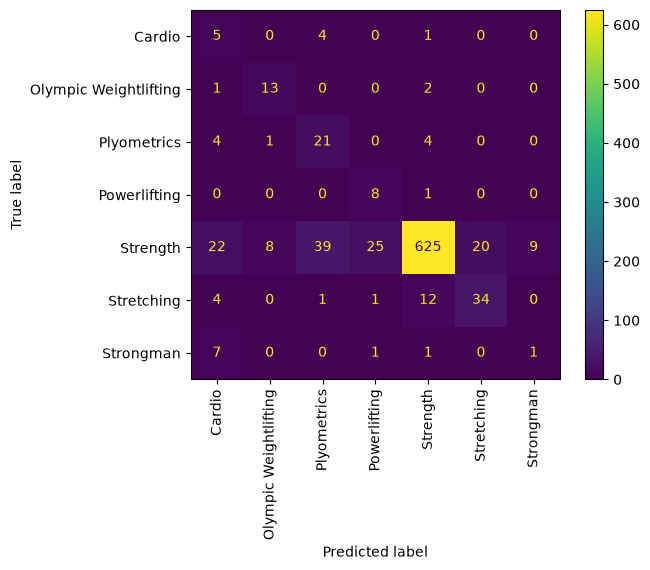

In [36]:
# 3. Per-class precision/recall/F1 — more informative than accuracy alone
print(classification_report(y_test, y_pred))

# 4. Confusion matrix — shows which categories get confused with each other
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=90)

In [22]:
X = df.Title
y = df.Type

In [25]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.47865829758987033 0.04229069873802512


In [26]:
scores

array([0.55088321, 0.41018817, 0.47305294, 0.5500565 , 0.49431905,
       0.44586455, 0.48631538, 0.47003833, 0.45901712, 0.44684772])

In [27]:
cv

StratifiedKFold(n_splits=10, random_state=290726, shuffle=True)

In [32]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.47865829758987033 0.04229069873802512


# Try the linearSVM Pipeline

In [38]:
from sklearn.svm import LinearSVC, SVC

## Linear SVM

In [39]:
linear_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
])


In [40]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(linear_pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.55341150990237 0.06403439043936063


In [47]:
param_grid = {"clf__C": [0.1, 1, 10, 100]}
grid = GridSearchCV(linear_pipe, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information 

In [49]:
grid.best_params_

{'clf__C': 1}

In [50]:
grid.best_score_

np.float64(0.5017010190282399)

## RBF pipeline

In [41]:
rbf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english", max_features=5000)),
    ("clf", SVC(kernel="rbf", class_weight="balanced"))
])

In [42]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=290726)
scores = cross_val_score(rbf_pipe, X, y, cv=cv, scoring='f1_macro')
print(scores.mean(), scores.std())

0.512741171243172 0.05590147043710734


# New Suggested Pipeline

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# word + char n-grams together — char n-grams catch shared roots like
# "jump"/"jumping" and "stretch"/"stretching" even with different suffixes
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1,2), min_df=1, stop_words="english")),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=1)),
])

svm_pipe = Pipeline([("feats", vectorizer), ("clf", LinearSVC(class_weight="balanced", max_iter=5000))])
nb_pipe  = Pipeline([("feats", vectorizer), ("clf", ComplementNB())])

cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
for name, pipe in [("SVM", svm_pipe), ("ComplementNB", nb_pipe)]:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(name, scores.mean(), scores.std())

SVM 0.570029654749321 0.0433411097544553
ComplementNB 0.4627005048362894 0.03785354633136425


In [53]:
scores

array([0.43081756, 0.51888914, 0.48315523, 0.47930485, 0.45378302,
       0.3893243 , 0.49973229, 0.48830822, 0.46393797, 0.41927225,
       0.45625132, 0.4328313 , 0.45648208, 0.53592785, 0.43249019])